>
> # Scenario analysis
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [401]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import json
from scipy.stats import t
import re
from scenarios import *
from plot_func import *
import seaborn as sns
import matplotlib.collections

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Enter variable and data type
variable = {"name": "gini", "sym": "$G$", "int": False}

In [4]:
# Loop through zip files
dir_name = os.path.join(os.getcwd(),'input',variable["name"])
res, micro, params, drivers, requests, var_val, all_pax = load_results(dir_name, variable)

# Find variable values that have been tested
vals, scn = find_vals(var_val, variable)

In [6]:
# Compute additional (aggregated) day-to-day indicators, incl. standard deviations, properties of agent groups, and relative indicators
res = add_indicators(micro, params, drivers, requests, res, all_pax)

C:\Users\arjanderuijter\Programming\MaaSSim\scenarios\scenarios.py:142: RuntimeWarning: divide by zero encountered in log
  logsum_alts = np.log(exp_U_alts)
C:\Users\arjanderuijter\Programming\MaaSSim\scenarios\scenarios.py:142: RuntimeWarning: divide by zero encountered in log
  logsum_alts = np.log(exp_U_alts)
C:\Users\arjanderuijter\Programming\MaaSSim\scenarios\scenarios.py:142: RuntimeWarning: divide by zero encountered in log
  logsum_alts = np.log(exp_U_alts)
C:\Users\arjanderuijter\Programming\MaaSSim\scenarios\scenarios.py:142: RuntimeWarning: divide by zero encountered in log
  logsum_alts = np.log(exp_U_alts)
C:\Users\arjanderuijter\Programming\MaaSSim\scenarios\scenarios.py:142: RuntimeWarning: divide by zero encountered in log
  logsum_alts = np.log(exp_U_alts)
C:\Users\arjanderuijter\Programming\MaaSSim\scenarios\scenarios.py:142: RuntimeWarning: divide by zero encountered in log
  logsum_alts = np.log(exp_U_alts)
C:\Users\arjanderuijter\Programming\MaaSSim\scenarios\scen

In [7]:
for i in range(len(res.sup)):
    if 'rejected_reg' not in res.sup[i].columns:
        res.sup[i]['rejected_reg'] = np.zeros(len(res.sup[i].index))
        res.sup[i]['reject_particip'] = np.zeros(len(res.sup[i].index))

In [8]:
# Find equilibrium values for all runs
conv_repl = determine_eql(res, params)
conv_repl.head(10)

all replications have converged


,t_sup*,perc_inc_reg*,t_dem*,perc_wait*,t*,converged
0,41,119.006625,37,1443.348249,41,True
1,9,161.563353,36,1491.052055,36,True
2,41,106.820022,35,1471.111503,41,True
3,38,134.361175,33,1448.123205,38,True
4,34,162.105385,33,1492.904629,34,True
5,7,163.053403,32,1530.663095,32,True
6,25,144.297107,36,1462.216398,36,True
7,42,136.148377,32,1239.958742,42,True
8,29,133.994079,31,1241.489227,31,True
9,26,130.665996,29,1272.522766,29,True


In [9]:
# Convert indicators of individual runs to indicators for scenarios
eql_runs, eql_scn, d2d, params_scn = runs_to_scenarios(res, params, vals, scn)

Sufficient number of replications: 3/0 for scenario 0.0
Sufficient number of replications: 3/0 for scenario 0.05
Sufficient number of replications: 8/4 for scenario 0.1
Sufficient number of replications: 4/2 for scenario 0.15
Sufficient number of replications: 4/2 for scenario 0.2
Sufficient number of replications: 5/1 for scenario 0.25
Sufficient number of replications: 3/1 for scenario 0.3
Sufficient number of replications: 3/1 for scenario 0.35
Sufficient number of replications: 3/1 for scenario 0.4
Sufficient number of replications: 3/1 for scenario 0.45
Sufficient number of replications: 3/1 for scenario 0.5
Sufficient number of replications: 3/1 for scenario 0.55
Sufficient number of replications: 3/1 for scenario 0.6
Sufficient number of replications: 3/1 for scenario 0.65
Sufficient number of replications: 3/1 for scenario 0.7
Sufficient number of replications: 3/1 for scenario 0.75
Sufficient number of replications: 3/1 for scenario 0.8
Sufficient number of replications: 3/1 f

In [10]:
# Create d2d statistics
res_scn = d2d_stats(d2d, vals, res)

In [11]:
eql_scn.dem

,inform,requests,gets_offer,accepts_offer,mean_wait,corr_mean_wait,perc_wait,perc_wait_req,bike,car,...,std_exp_wait,std_corr_wait,std_perc_wait_req,cons_surplus,pickup_time,match_time,corr_match_time,extra_bike,extra_pt,extra_car
scenario,,,,,,,,,,,,,,,,,,,,,
0.00,16538.000000,151.066667,0.000000,0.000000,NaN,1800.000000,1656.159190,1569.489841,13346.333333,1757.333333,...,NaN,0.000000,311.942220,9.823645,NaN,NaN,NaN,41820.333333,5116.666667,9181.666667
0.05,18255.000000,151.533333,0.000000,0.000000,NaN,1800.000000,1675.317652,1579.746994,14626.000000,2061.000000,...,NaN,0.000000,319.965986,9.249856,NaN,NaN,NaN,40586.666667,4961.000000,8922.000000
0.10,21182.500000,284.500000,0.617517,178.325000,596.655283,1052.790968,1227.788948,1066.839593,16603.675000,2712.800000,...,307.524615,590.747540,357.413625,30.296181,389.310069,207.345214,NaN,38706.750000,4764.875000,8250.750000
0.15,23081.500000,581.500000,0.943309,548.850000,445.724960,521.221730,685.283217,572.366860,17531.350000,3300.950000,...,295.865167,415.436858,250.058269,107.518101,373.441555,72.283405,NaN,37571.750000,4690.000000,7728.500000
0.20,23872.000000,913.900000,0.993139,907.700000,258.062314,268.493694,386.781735,332.762865,17582.000000,3694.300000,...,213.848615,242.994453,168.501691,248.216490,249.480886,8.581427,NaN,37235.250000,4729.000000,7325.500000
0.25,24070.200000,1161.360000,0.999023,1160.200000,210.562989,212.097748,268.168363,231.393143,17277.760000,4017.720000,...,190.144632,195.253693,126.216339,429.549140,209.000932,1.562057,NaN,37337.800000,4788.600000,7050.000000
0.30,23836.333333,1396.666667,1.000000,1396.666667,162.240341,162.240341,205.533172,180.701276,16654.200000,4226.466667,...,148.544638,148.544638,98.727514,758.079606,163.794800,-1.554459,NaN,37659.333333,4936.666667,6885.000000
0.35,23290.666667,1650.066667,1.000000,1650.066667,139.297599,139.297599,158.938408,142.658112,15864.866667,4315.200000,...,136.703689,136.703689,77.422756,1445.461474,140.873658,-1.576059,NaN,38249.666667,5090.666667,6729.000000
0.40,22533.333333,1931.333333,1.000000,1931.333333,104.806772,104.806772,129.687668,116.724983,14915.200000,4320.800000,...,108.416541,108.416541,67.852559,2823.646559,106.379709,-1.572937,NaN,38970.333333,5250.666667,6639.666667


In [12]:
eql_scn.sup

,inform,regist,rejected_reg,particip,reject_particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,...,driver_surplus,mean_rev,mean_op_costs,ivt_costs,dh_costs,mean_dh_dist,mean_dh_time,drive_time,not_idle_time,share_idle_time
scenario,,,,,,,,,,,,,,,,,,,,,
0.00,2500.0,0.000000,0.0,0.000000,0.0,114.484359,NaN,NaN,NaN,0.572422,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.05,2500.0,0.000000,0.0,0.000000,0.0,122.288158,NaN,NaN,NaN,0.615843,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.10,2500.0,63.525000,0.0,4.925000,0.0,133.357334,132.847539,132.341527,133.947121,0.689604,...,-1239.534131,206.654617,72.707496,36.578253,36.129243,144.516970,14451.697043,14631.301274,29082.998316,-0.009826
0.15,2500.0,75.550000,0.0,18.350000,0.0,121.702856,121.610281,120.419877,120.630173,0.654309,...,-1163.131647,181.831380,61.201206,32.847540,28.353667,113.414667,11341.466653,13139.015904,24480.482557,0.149983
0.20,2500.0,96.400000,0.0,40.250000,0.0,108.412867,108.494325,107.679084,105.139620,0.615029,...,-974.419987,146.150610,41.010990,26.820432,14.190559,56.762235,5676.223509,10728.172637,16404.396146,0.430403
0.25,2500.0,118.840000,0.0,59.840000,0.0,96.371383,97.098102,95.798245,97.363783,0.590088,...,-622.854069,132.028906,34.665123,24.479326,10.185797,40.743186,4074.318645,9791.730563,13866.049208,0.518540
0.30,2500.0,146.800000,0.0,87.333333,0.0,84.108193,85.049396,84.470268,84.626811,0.561008,...,-599.763431,112.107339,27.480529,20.908492,6.572037,26.288148,2628.814763,8363.396656,10992.211419,0.618326
0.35,2500.0,182.266667,0.0,117.533333,0.0,77.037274,78.315871,77.434845,77.686458,0.574386,...,-252.419727,101.762815,24.076357,19.093367,4.982990,19.931960,1993.195985,7637.346857,9630.542842,0.665606
0.40,2500.0,223.533333,0.0,159.266667,0.0,70.646800,71.499915,70.779782,69.077005,0.617333,...,175.816016,89.064813,19.987808,16.757404,3.230404,12.921616,1292.161619,6702.961584,7995.123203,0.722392


In [13]:
eql_scn.plf

,plat_profit
0.00,242.050825
0.05,257.111925
0.10,527.486400
0.15,1168.867875
0.20,1968.077662
0.25,2628.676995
0.30,3258.503200
0.35,3975.291825
0.40,4724.434450
0.45,5494.748300


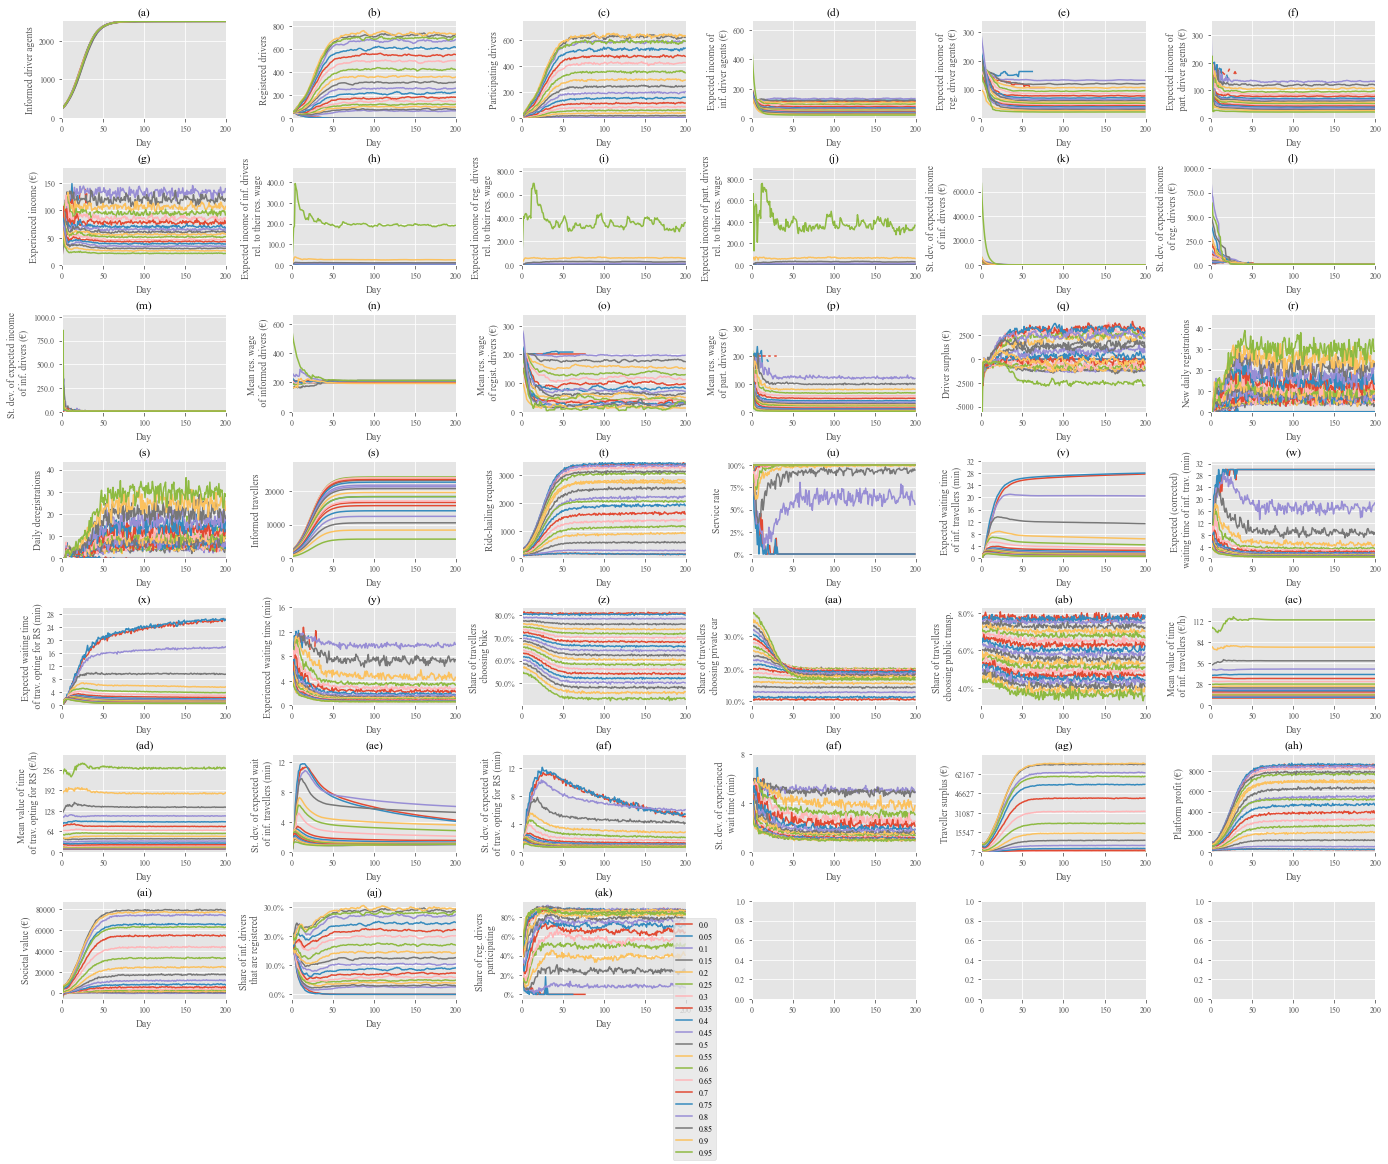

In [14]:
# Plot all indicators in one graph
fig = plot_multi_graph(res_scn, vals)
fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], variable["name"] + '_multi_fig.jpg'),dpi=300,bbox_inches='tight')

<AxesSubplot:xlabel='day', ylabel='Volume of informed drivers'>

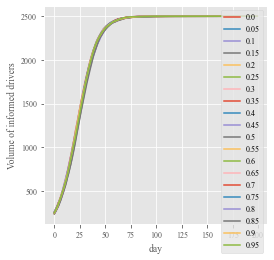

In [15]:
# Plot an individual indicator
plot_inform = res_scn.sup.inform.plot()
plot_inform.set_ylabel("Volume of informed drivers")
plot_inform

In [16]:
# kpi_eq.informed_drivers = round(kpi_eq.informed_drivers).astype(int)
# kpi_eq.regist_drivers = round(kpi_eq.regist_drivers).astype(int)
# kpi_eq.particip_drivers = round(kpi_eq.particip_drivers).astype(int)
# kpi_eq.requests = round(kpi_eq.requests).astype(int)
# kpi_eq.mean_perc_inc = round(kpi_eq.mean_perc_inc,2)
# kpi_eq.std_perc_inc = round(kpi_eq.std_perc_inc,2)
# kpi_eq.mean_exp_inc = round(kpi_eq.mean_exp_inc,2)
# kpi_eq.std_exp_inc = round(kpi_eq.std_exp_inc,2)
# kpi_eq.service_rate = round(kpi_eq.service_rate,1)
# kpi_eq.mean_wait_time = round(kpi_eq.mean_wait_time).astype(int)
# kpi_eq.exp_pure_wait = round(kpi_eq.exp_pure_wait).astype(int)
# kpi_eq.exp_wait_time = round(kpi_eq.exp_wait_time).astype(int)
# kpi_eq.std_perc_wait = round(kpi_eq.std_perc_wait).astype(int)
# kpi_eq.std_exp_wait = round(kpi_eq.std_exp_wait).astype(int)
# kpi_eq.std_corr_exp_wait = round(kpi_eq.std_corr_exp_wait).astype(int)
# kpi_eq.plf_profit = round(kpi_eq.plf_profit).astype(int)
# # kpi_eq = kpi_eq.drop(['perc_pax_reject'],axis=1)
# kpi_eq = kpi_eq[['informed_drivers','regist_drivers','particip_drivers', 'requests','mean_perc_inc','std_perc_inc','mean_exp_inc','std_exp_inc','service_rate','mean_wait_time','std_perc_wait','exp_pure_wait','std_exp_wait','exp_wait_time','std_corr_exp_wait','plf_profit']]

# Print equilibrium indicators as LateX table
print(eql_scn.sup.astype('str').T.to_latex(index=True))
print(eql_scn.dem.astype('str').T.to_latex(index=True))
print(eql_scn.plf.astype('str').T.to_latex(index=True))

\begin{tabular}{lllllllllllllllllllll}
\toprule
scenario &                0.00 &                0.05 &                   0.10 &                 0.15 &                 0.20 &                0.25 &                0.30 &                0.35 &                0.40 &                0.45 &                0.50 &                0.55 &                0.60 &                0.65 &                0.70 &                0.75 &                0.80 &                 0.85 &                 0.90 &                0.95 \\
\midrule
inform             &              2500.0 &              2500.0 &                 2500.0 &               2500.0 &               2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &               2500.0 &               2500.0 &              2500.0 \\
regist         

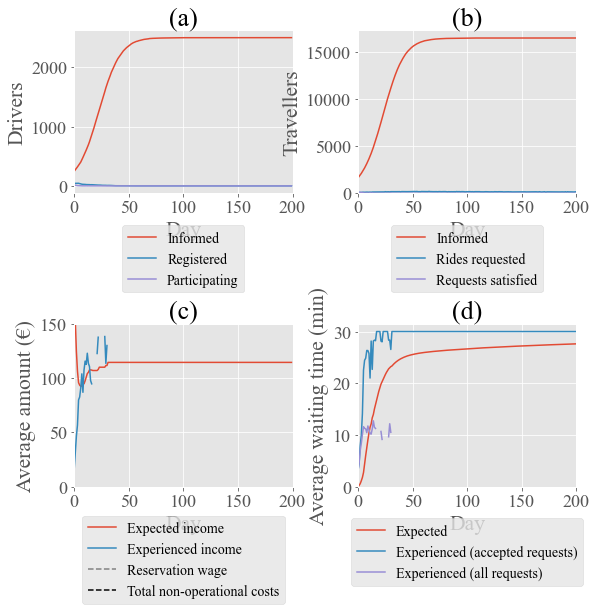

In [605]:
# Plot indicators for single scenario (e.g. base scenario)
value = 0.0 # specific scenario
fig = plot_single_scenario(res_scn, value)
fig.savefig(os.path.join(os.getcwd(),"plots",'base_scenario'+'.jpg'), bbox_inches='tight', dpi=300)

---

In [18]:
# KPIs
kpis_sup = eql_scn.sup.columns
kpis_dem = eql_scn.dem.columns
kpis_plf = ['plat_profit']

In [19]:
# Find societal value
eql_scn.soc = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus + eql_scn.plf.plat_profit
eql_scn.soc = pd.DataFrame(eql_scn.soc.values, index = vals, columns = ['soc_value'])

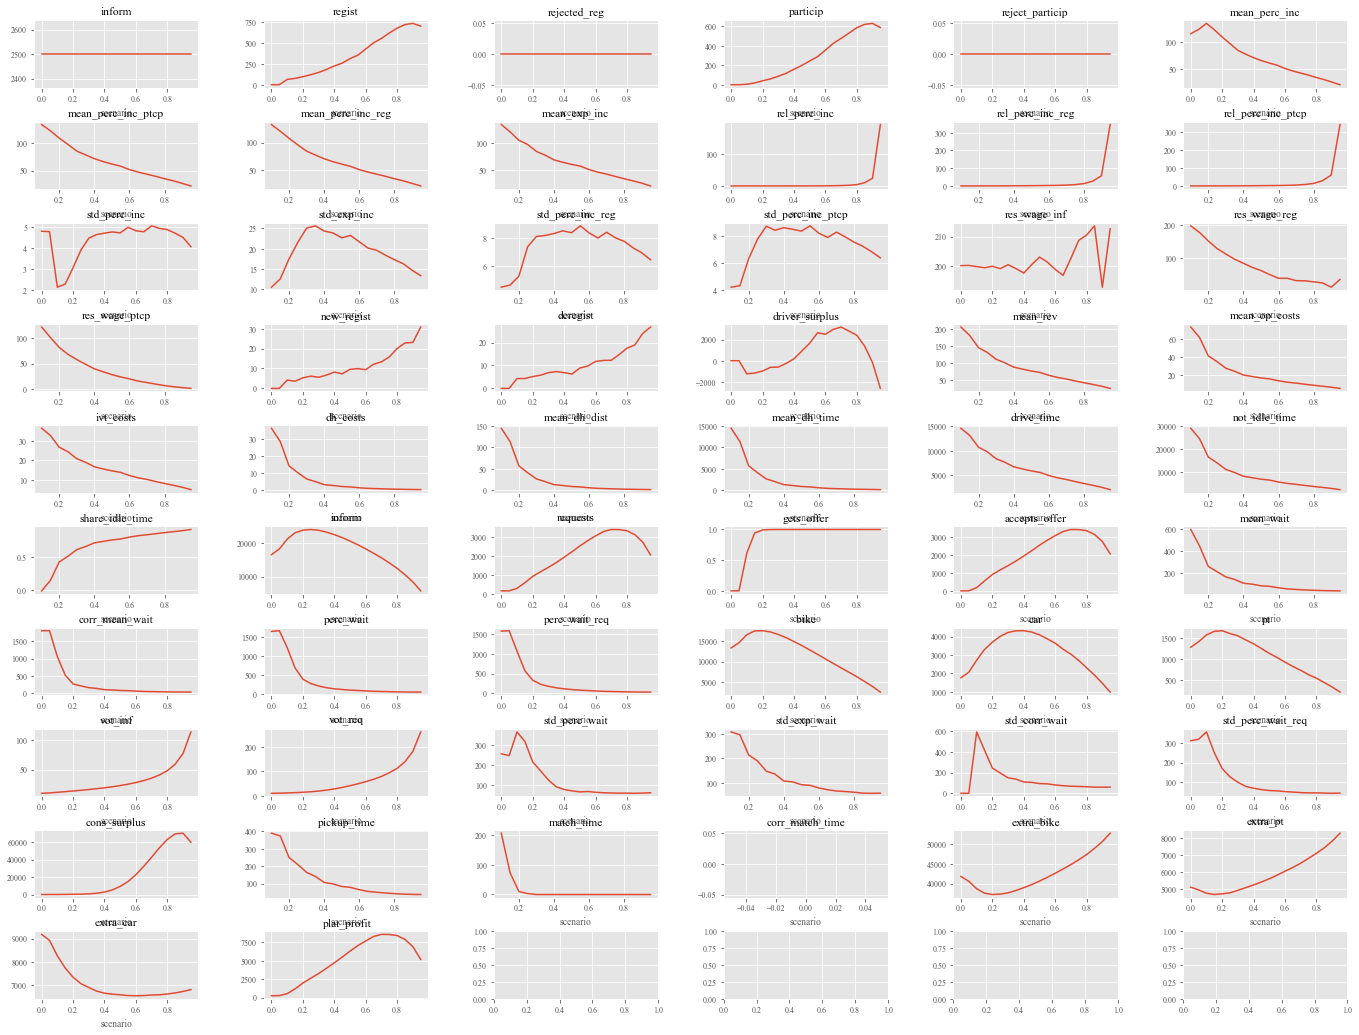

In [23]:
fig, axes = plt.subplots(10, 6, figsize = [24,18])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)
i = 0
j = 0

for kpi in kpis_sup:
    axes[j, i] = eql_scn.sup[kpi].plot(ax=axes[j,i])
    axes[j, i].set_title(kpi)
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_dem:
    axes[j, i] = eql_scn.dem[kpi].plot(ax=axes[j,i])
    axes[j, i].set_title(kpi)
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_plf:
    axes[j, i] = eql_scn.plf[kpi].plot(ax=axes[j,i])
    axes[j, i].set_title(kpi)
    i += 1
    if i > 5:
        i = 0
        j += 1

fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], 'effect.jpg'),dpi=300,bbox_inches='tight')


In [63]:
res_proc = pd.DataFrame(index = eql_scn.sup.index)
# res_proc['gini'] = eql_scn.sup.gini
res_proc['exp_inc'] = eql_scn.sup.mean_exp_inc.copy()
res_proc['wait_time'] = eql_scn.dem.mean_wait / 60
res_proc['driv_per_req'] = eql_scn.sup.particip / eql_scn.dem.requests
res_proc['mode_share'] = eql_scn.dem.requests / params[0]['nP']
res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip
res_proc['regist'] = eql_scn.sup.regist / eql_scn.sup.inform
res_proc['ptcp_prob'] = eql_scn.sup.particip / eql_scn.sup.regist
res_proc['match_rate'] = eql_scn.dem.gets_offer.copy()
res_proc['match_time'] = eql_scn.dem.match_time / 60
res_proc['pickup_time'] = eql_scn.dem.pickup_time / 60
res_proc['dh_time'] = eql_scn.sup.mean_dh_time / (params[0]['simTime'] * 3600)
res_proc['idle_time'] = eql_scn.sup.share_idle_time

In [64]:
res_proc

,exp_inc,wait_time,driv_per_req,mode_share,earn_req_sat,serv_req_part,regist,ptcp_prob,match_rate,match_time,pickup_time,dh_time,idle_time
scenario,,,,,,,,,,,,,
0.00,NaN,NaN,0.000000,0.002014,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN
0.05,NaN,NaN,0.000000,0.002020,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN
0.10,133.947121,9.944255,0.017311,0.003793,3.754989,35.671779,0.025410,0.077529,0.617517,3.455754,6.488501,0.501795,-0.009826
0.15,120.630173,7.428749,0.031556,0.007753,4.035416,29.892871,0.030220,0.242886,0.943309,1.204723,6.224026,0.393801,0.149983
0.20,105.139620,4.301039,0.044042,0.012185,4.662550,22.549813,0.038560,0.417531,0.993139,0.143024,4.158015,0.197091,0.430403
0.25,97.363783,3.509383,0.051526,0.015485,5.021654,19.388789,0.047536,0.503534,0.999023,0.026034,3.483349,0.141469,0.518540
0.30,84.626811,2.704006,0.062530,0.018622,5.291700,15.992366,0.058720,0.594914,1.000000,-0.025908,2.729913,0.091278,0.618326
0.35,77.686458,2.321627,0.071229,0.022001,5.533563,14.039138,0.072907,0.644843,1.000000,-0.026268,2.347894,0.069208,0.665606
0.40,69.077005,1.746780,0.082465,0.025751,5.696409,12.126413,0.089413,0.712496,1.000000,-0.026216,1.772995,0.044867,0.722392


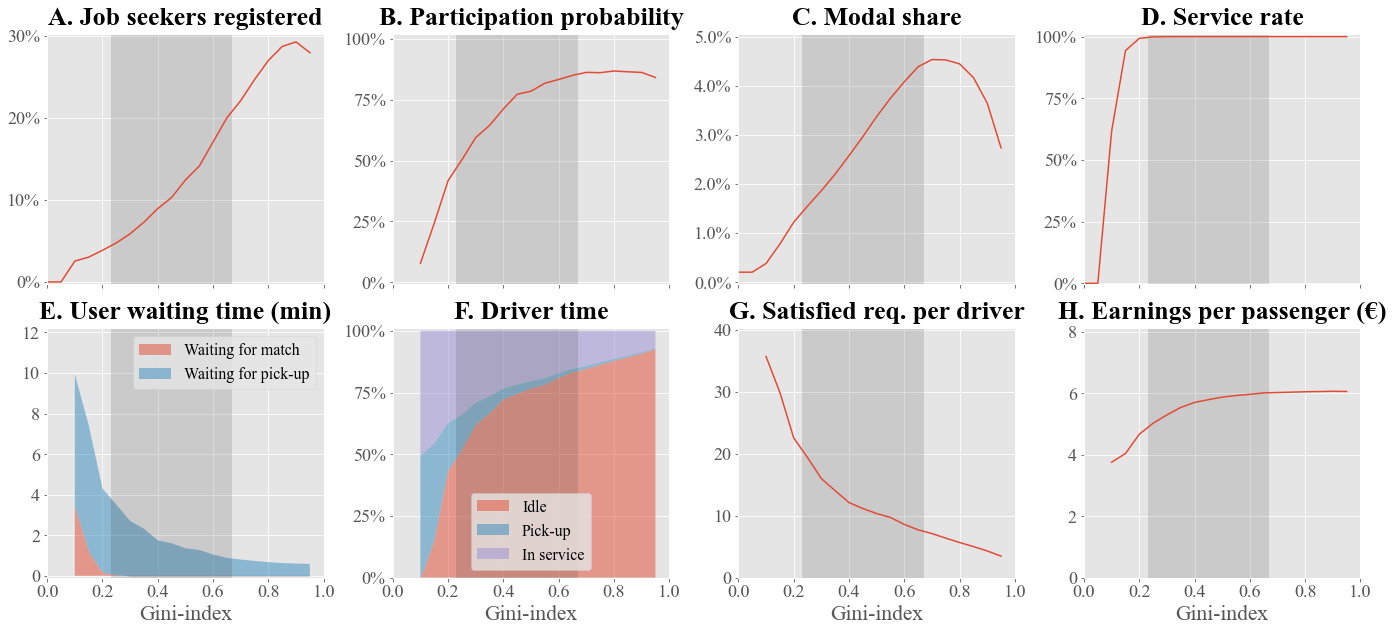

In [81]:
fig, axes = plt.subplots(2, 4, figsize = [24,10],sharex=True)
# plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.18, wspace=0.25, left=.12, right=.88)
plt.setp(axes, xlim=[0,1],xticks=np.arange(0, 1.2, step=0.2))
# locs, labels = plt.xticks()
# xticks(np.arange(0, 2500, step=500))
gini_min = 0.23
gini_max = 0.67

# eql_scn.sup.regist.plot(ax = axes[0,0])
res_proc.regist.plot(ax=axes[0,0],legend=None)
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[0, 0].set_ylabel('Job seekers registered')
axes[0, 0].set_xlabel('Job seekers')
axes[0, 0].set_title('A. Job seekers registered',fontweight="bold",pad=10)
axes[0, 0].set_ylim(bottom = -0.002, top = 0.302)
axes[0, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1,decimals=0)) 
axes[0, 0].locator_params(axis='y', nbins=5)
# axes[0,0].axvline(x=0.23,linestyle='--',c='grey')
# axes[0,0].axvline(x=0.64,linestyle='--',c='grey')
axes[0, 0].axvspan(gini_min, gini_max, facecolor='0.2', alpha=0.15)
# plt.axvspan(i, i+.5, facecolor='b', alpha=0.5)

res_proc.ptcp_prob.plot(ax=axes[0,1],legend=None, marker='')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[0, 1].set_ylabel('Participation probability')
axes[0, 1].set_xlabel('Gini')
axes[0, 1].set_title('B. Participation probability',fontweight="bold",pad=10)
axes[0, 1].set_ylim(bottom = -0.006, top = 1.02)
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[0, 1].locator_params(axis='y', nbins=5)
axes[0, 1].axvspan(gini_min, gini_max, facecolor='0.2', alpha=0.15)

res_proc.mode_share.plot(ax=axes[0,2],legend=None, marker='')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[0, 2].set_ylabel('Modal share')
# axes[0, 2].set_xlabel('nV')
axes[0, 2].set_title('C. Modal share', fontweight="bold",pad=10)
axes[0, 2].set_ylim(bottom = -0.0003, top = 0.0505)
axes[0, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1,decimals=1)) 
axes[0, 2].locator_params(axis='y', nbins=6)
axes[0, 2].axvspan(gini_min, gini_max, facecolor='0.2', alpha=0.15)

res_proc.match_rate.plot(ax=axes[0,3],legend=None, marker='')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[0, 3].set_ylabel('Service rate')
axes[0, 3].set_xlabel('Gini-index')
axes[0, 3].set_title('D. Service rate', fontweight="bold",pad=10)
axes[0, 3].set_ylim(bottom = -0.001, top = 1.01)
axes[0, 3].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[0, 3].locator_params(axis='y', nbins=5)
axes[0, 3].axvspan(gini_min, gini_max, facecolor='0.2', alpha=0.15)

# res_proc.sort_values(by=['nP']).plot(x='nV',y='match_time',ax=axes[1,0],label='Match time')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[1, 0].set_ylabel('E. User waiting time')
axes[1, 0].set_xlabel('Gini-index')
axes[1, 0].set_title('E. User waiting time (min)', fontweight="bold",pad=10)
axes[1, 0].set_ylim(bottom = -2, top = 100)
# axes[1, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[1, 0].locator_params(axis='y', nbins=5)

x = res_proc.index.values
y1 = res_proc.match_time
y2 = res_proc.pickup_time
axes[1, 0].stackplot(x,y1,y2, alpha=0.5)
axes[1, 0].legend(['Waiting for match','Waiting for pick-up'],fontsize=16)



# axes[1, 0].set_ylabel('Pickup time')
axes[1, 0].set_xlabel('Gini-index')
# axes[1, 0].set_title('(f)')
axes[1, 0].set_ylim(bottom = -0.1, top = 12.2)
# axes[1, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[1, 0].locator_params(axis='y', nbins=7)
axes[1, 0].axvspan(gini_min, gini_max, facecolor='0.2', alpha=0.15)

# res_proc.sort_values(by=['nP']).plot(x='nV',y='match_time',ax=axes[1,0],marker='o',linestyle='')
# res_proc.sort_values(by=['nP']).plot(x='nV',y='pickup_time',ax=axes[1,0],marker='o',linestyle='')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)



# res_proc.sort_values(by=['nP']).plot(x='nV',y='idle_time',ax=axes[1,1], label='Idle',marker='o',linestyle='',mfc='k')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[1, 1].set_ylabel('Driver idle time')

res_proc['dh_time'] = eql_scn.sup.mean_dh_time / (params[0]['simTime'] * 3600)
# res_proc.sort_values(by=['nP']).plot(x='nV',y='dh_time',ax=axes[1,1], label='Pick-up')
x = res_proc.index.values
y1 = res_proc.idle_time
y2 = res_proc.dh_time
y3 = 1 - y1 - y2
axes[1, 1].stackplot(x,y1,y2,y3, alpha=0.5)
axes[1, 1].legend(['Idle','Pick-up','In service'],loc='lower center',fontsize=16)



axes[1, 1].set_xlabel('Gini-index')
axes[1, 1].set_title('F. Driver time', fontweight="bold",pad=10)
axes[1, 1].set_ylim(bottom = -0.001, top = 1.01)
axes[1, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[1, 1].locator_params(axis='y', nbins=5)
axes[1, 1].axvspan(gini_min, gini_max, facecolor='0.2', alpha=0.15)

# axes[1, 1].plot((res_scn.sup.mean_dh_time / (params[0]['simTime'] * 3600)).rolling(5, min_periods=1).mean(),label='Deadheading')

res_proc.serv_req_part.plot(ax=axes[1,2],legend=None, marker='')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[1, 2].set_ylabel('Satisfied requests per driver')
axes[1, 2].set_xlabel('Gini-index')
axes[1, 2].set_title('G. Satisfied req. per driver',fontweight="bold",pad=10)
axes[1, 2].set_ylim(bottom = -0.002, top = 40.2)
# axes[1, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[1, 2].locator_params(axis='y', nbins=5)
axes[1, 2].axvspan(gini_min, gini_max, facecolor='0.2', alpha=0.15)

res_proc.earn_req_sat.plot(ax=axes[1,3],legend=None, marker='')
# axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / sup_vol)
# axes[1, 3].set_ylabel('Earnings per passenger')
axes[1, 3].set_xlabel('Gini-index')
axes[1, 3].set_title('H. Earnings per passenger (€)', fontweight="bold",pad=10)
axes[1, 3].set_ylim(bottom = -0.001, top = 8.1)
# axes[1, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[1, 3].locator_params(axis='y', nbins=5)
axes[1, 3].axvspan(gini_min, gini_max, facecolor='0.2', alpha=0.15)

fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], 'indicators.jpg'),dpi=300,bbox_inches='tight')

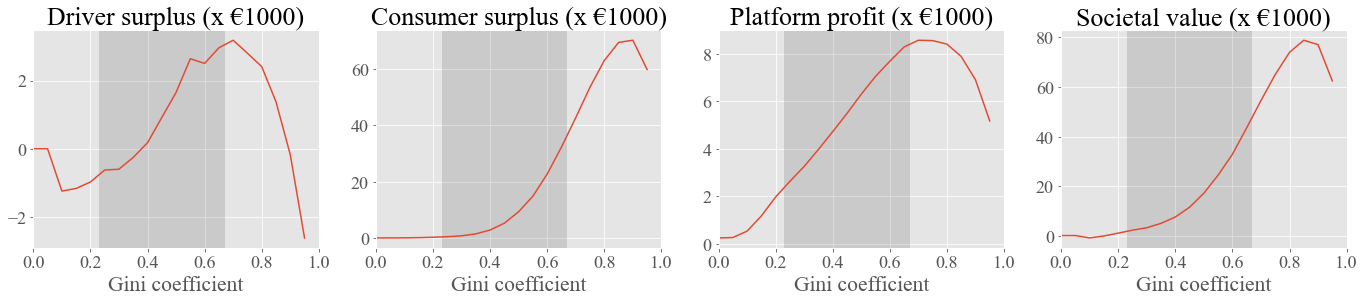

In [97]:
# Plot societal indicators
plt.rc('font', size=18)
plt.rc('xtick', labelsize=18) 
plt.rc('ytick', labelsize=18) 
fig, axes = plt.subplots(1, 4, figsize = [24,4])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.2, left=.12, right=.88)

axes[0] = (eql_scn.sup.driver_surplus/1000).plot(ax=axes[0])
axes[0].set_title('Driver surplus (x \u20ac1000)')
axes[0].set_xlabel('Gini coefficient')
axes[0].set_xlim([0, 1])
# axes[0].axvline(x=0.23,linestyle='--',c='grey')
# axes[0].axvline(x=0.64,linestyle='--',c='grey')
axes[0].axvspan(gini_min, gini_max, facecolor='0.2', alpha=0.15)

axes[1] = (eql_scn.dem.cons_surplus/1000).plot(ax=axes[1])
axes[1].set_title('Consumer surplus (x \u20ac1000)')
axes[1].set_xlabel('Gini coefficient')
axes[1].set_xlim([0, 1])
# axes[1].axvline(x=0.23,linestyle='--',c='grey')
# axes[1].axvline(x=0.64,linestyle='--',c='grey')
axes[1].axvspan(gini_min, gini_max, facecolor='0.2', alpha=0.15)

axes[2] = (eql_scn.plf.plat_profit/1000).plot(ax=axes[2])
axes[2].set_title('Platform profit (x \u20ac1000)')
axes[2].set_xlabel('Gini coefficient')
axes[2].set_xlim([0, 1])
# axes[2].axvline(x=0.23,linestyle='--',c='grey')
# axes[2].axvline(x=0.64,linestyle='--',c='grey')
axes[2].axvspan(gini_min, gini_max, facecolor='0.2', alpha=0.15)

axes[3] = (eql_scn.soc.soc_value/1000).plot(ax=axes[3])
axes[3].set_title('Societal value (x \u20ac1000)')
axes[3].set_xlabel('Gini coefficient')
axes[3].set_xlim([0, 1])
# axes[3].axvline(x=0.23,linestyle='--',c='grey')
# axes[3].axvline(x=0.64,linestyle='--',c='grey')
axes[3].axvspan(gini_min, gini_max, facecolor='0.2', alpha=0.15)

fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], 'societal_value.jpg'),dpi=300,bbox_inches='tight')

<AxesSubplot:>

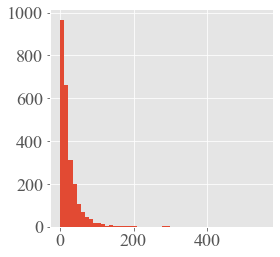

In [96]:
(drivers[40].res_wage / 8).hist(bins=50)

In [94]:
micro.dem.requests[5]

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
pax_id,,,,,,,,,,,,,,,,,,,,,
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18165,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
18166,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
18167,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [95]:
requests[5]

,origin,destination,treq,dist,haver_dist,VoT,U_car,U_pt,U_bike
pax_id,,,,,,,,,
0,896347548,442534806,2021-11-01 12:23:12,3189,2416.768969,9.599342,-2.460525,-3.280793,-0.674962
1,46434000,46350260,2021-11-01 14:59:02,3574,2788.614898,11.520332,-2.640393,-3.288563,-0.909377
2,811277640,46390769,2021-11-01 13:42:29,5773,4199.623273,12.206001,-2.981475,-4.205498,-1.557255
3,3649050877,6949114049,2021-11-01 14:46:42,3628,2013.845077,9.020633,-3.668253,-2.853185,-0.722031
4,46300892,46385942,2021-11-01 13:26:31,3785,2359.499363,10.448486,-3.787011,-3.003143,-0.873284
...,...,...,...,...,...,...,...,...,...
18165,415961034,46415826,2021-11-01 13:01:28,2936,2349.733421,10.722870,-3.698192,-2.834348,-0.694687
18166,605221730,46516697,2021-11-01 16:47:11,2424,2068.287733,8.860502,-2.320652,-2.698694,-0.474116
18167,2311089897,46427652,2021-11-01 09:20:26,2763,2285.514700,9.162870,-3.574775,-2.774707,-0.559179


In [593]:
# sel_vals = [0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75]
# sel_vals = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
sel_vals = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# sel_vals = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
# sel_vals = np.arange(0.05,1,0.05)

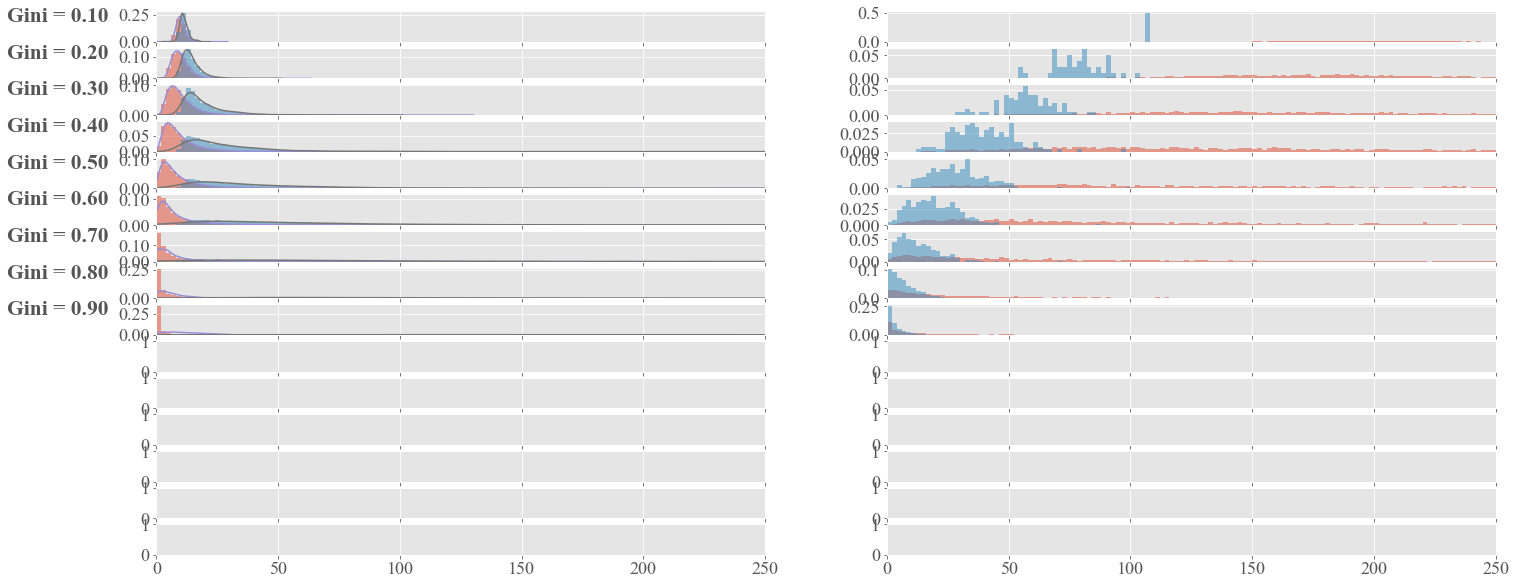

In [594]:
fig, axes = plt.subplots(15, 2, figsize = [24,10],sharex=True)
# plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
# fig.subplots_adjust(hspace=.18, wspace=0.25, left=.12, right=.88)
plt.setp(axes, xlim=[0,250])
# rows = ['Gini = {}'.format(row) for row in sel_vals


x_loc = 0
for i in sel_vals:
    run_ids = scn[scn['val'] == i].index
    abc = requests[run_ids[0]]['VoT']
    distr = pd.DataFrame(requests[run_ids[0]]['VoT'])
    distr['req'] = micro.dem.requests[run_ids[0]]['199']
    defg = drivers[run_ids[0]]['res_wage']
    distr_sup = pd.DataFrame(drivers[run_ids[0]]['res_wage'])
    distr_sup['ptcp'] = micro.sup.ptcp[run_ids[0]]['199']
    for j in run_ids[1:3]:
        abc.append(requests[j]['VoT'])
        temp_distr = pd.DataFrame(requests[j]['VoT'])
        temp_distr['req'] = micro.dem.requests[j]['199']
        distr.append(temp_distr)
        defg.append(drivers[j]['res_wage'])
        temp_distr = pd.DataFrame(drivers[j]['res_wage'])
        temp_distr['ptcp'] = micro.sup.ptcp[j]['199']
        distr_sup.append(temp_distr)
    all_pax[run_ids[0]]['VoT'].hist(density=True,alpha=0.5,ax=axes[x_loc,0],bins=range(0,400,2))
    distr[distr['req']]['VoT'].hist(density=True,alpha=0.5,ax=axes[x_loc,0],bins=range(0,400,2))
    all_pax[run_ids[0]]['VoT'].plot.density(ax=axes[x_loc,0])
    distr[distr['req']]['VoT'].plot.density(ax=axes[x_loc,0])
    defg.hist(density=True,alpha=0.5,ax=axes[x_loc,1],bins=range(0,400,2))
    distr_sup[distr_sup['ptcp']]['res_wage'].hist(density=True,alpha=0.5,ax=axes[x_loc,1],bins=range(0,400,2))
    axes[x_loc,0].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    axes[x_loc,0].set_ylabel('Gini = {0:.2f}'.format(i),rotation=0,labelpad=60,weight='bold')
    x_loc += 1
# fig.tight_layout()
# fig.subplots_adjust(left=0.5)

In [595]:
complete_df = pd.DataFrame(columns=all_pax[0].columns)
complete_df_sup = pd.DataFrame(columns=drivers[0].columns)
for i in sel_vals:
    run_ids = scn[scn['val'] == i].index
    temp = all_pax[run_ids[0]]
#     temp_sup = drivers[run_ids[0]]
#     temp_sup['ptcp'] = micro.sup.ptcp[run_ids[0]]['199']
    for j in run_ids[:3]:
        temp.append(all_pax[j])
        temp['scn'] = i
        temp['filter_pax_id'] = (temp['mode_choice'] == 'day-to-day').cumsum()
        temp['filter_pax_id'] = temp['filter_pax_id'] * (temp['mode_choice'] == 'day-to-day')
        temp['filter_pax_id'] = temp['filter_pax_id'].replace(0, np.nan)
        sel_req = micro.dem.requests[j][micro.dem.requests[j]['199']]
        temp['req'] = temp['filter_pax_id'].apply(lambda x: x in sel_req.index.values)
        temp_sup = pd.DataFrame(drivers[j])
        temp_sup['scn'] = i
        temp_sup['ptcp'] = micro.sup.ptcp[j]['199']
        temp_sup['exp_inc'] = micro.sup.exp_inc[j]['199'] / 8
        complete_df = complete_df.append(temp)
        complete_df_sup = complete_df_sup.append(temp_sup)
complete_df['pax_id'] = complete_df.index
complete_df = complete_df.reset_index(drop=True)
complete_df
temp

,pos,event,platforms,VoT,U_bike,U_car,U_pt,ASC_rs,mode_choice,prob_rs,scn,filter_pax_id,req
0,896347548,travellerEvent.STARTS_DAY,[0],40.468945,-2.845506,-4.532781,-8.297734,-2.2497,day-to-day,0.241431,0.9,1.0,True
1,46429971,travellerEvent.STARTS_DAY,[0],1.695329,-0.132324,-1.960418,-1.968578,-2.2497,bike,0.029217,0.9,NaN,False
2,7890114045,travellerEvent.STARTS_DAY,[0],6.512717,-1.764042,-3.236517,-1595.276423,-2.2497,bike,0.014643,0.9,NaN,False
3,46434000,travellerEvent.STARTS_DAY,[0],122.700917,-9.685601,-10.295621,-18.404320,-2.2497,day-to-day,0.981538,0.9,2.0,False
4,5833554542,travellerEvent.STARTS_DAY,[0],51.485852,-5.009001,-5.647223,-14.578228,-2.2497,day-to-day,0.510954,0.9,3.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74995,46364922,travellerEvent.STARTS_DAY,[0],0.334003,-0.030575,-1.916383,-1.847134,-2.2497,bike,0.023523,0.9,NaN,False
74996,46410382,travellerEvent.STARTS_DAY,[0],3.348820,-0.415399,-2.270346,-2.142749,-2.2497,car,0.022222,0.9,NaN,False
74997,8253977564,travellerEvent.STARTS_DAY,[0],0.179880,-0.026290,-2.103960,-1.819752,-2.2497,bike,0.013363,0.9,NaN,False
74998,27471866,travellerEvent.STARTS_DAY,[0],0.046206,-0.004771,-1.938138,-1.769027,-2.2497,car,0.020343,0.9,NaN,False


In [596]:
temp['req'].sum()/75000

0.036066666666666664

In [597]:
micro.sup.keys()

odict_keys(['inform', 'regist', 'ptcp', 'perc_inc', 'exp_inc', 'particip'])

In [598]:
complete_df.VoT.min()

8.378599494616813e-06

In [599]:
complete_df_sup[complete_df_sup['scn'] == 0.9].ptcp.sum()

1895

In [600]:
complete_df_sup['res_wage_hour'] = complete_df_sup['res_wage'] / 8

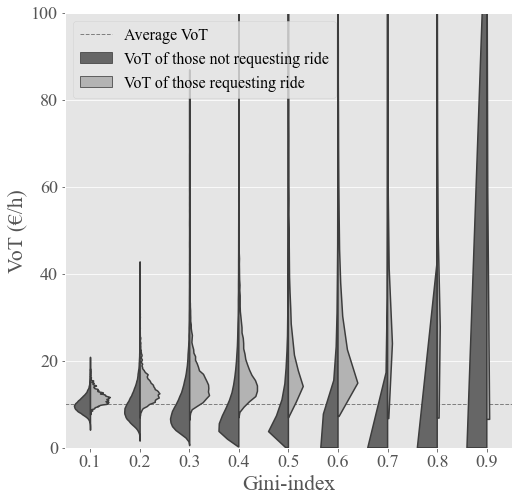

In [604]:
fig = plt.figure(figsize=(8,8))
ax = sns.violinplot(data=complete_df,x="scn",y="VoT",hue="req",split=True,inner=None,cut=0,palette=['.4', '.7'],bw=0.05)
ax.set(ylim=(0, 100))
ax.axhline(y=10,linewidth=1, color='grey',linestyle='--',zorder=-1)
ax.set_ylabel('VoT (€/h)')
ax.set_xlabel('Gini-index')
ax.legend(['Average VoT','VoT of those not requesting ride','VoT of those requesting ride'],fontsize=16, loc='upper left')
fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], 'vot-ptcp.jpg'),dpi=300,bbox_inches='tight')

In [492]:
# sellie = complete_df_sup[complete_df_sup['ptcp']]
# complete_df_sup['value'] = 

In [551]:
abc = complete_df_sup.copy()
abc['wage_true'] = True
abc['value'] = abc['res_wage_hour'] * abc['ptcp'].apply(lambda x: 1 if x else np.nan)
defg = complete_df_sup.copy()
defg['wage_true'] = False
defg['value'] = defg['exp_inc']
abc = abc.append(defg)
abc
abc[abc['scn']==0.9]['value'].sum()
# abc[abc['scn']==0.9]['value'].sum()
defg[defg['scn']==0.9]['value'].sum()
abc[abc['scn']==0.9]['exp_inc'].count()
abc[abc['scn']==0.9]['res_wage_hour'].apply(lambda x: 1 if x else np.nan)

,pos,res_wage,veh,scn,ptcp,exp_inc,res_wage_hour,wage_true,value
1,46482076,1.975474,1,0.9,False,NaN,0.246934,True,NaN
2,46517247,293.071481,2,0.9,False,NaN,36.633935,True,NaN
3,46253226,59.995044,3,0.9,False,NaN,7.499381,True,NaN
4,46392805,10.863923,4,0.9,False,NaN,1.357990,True,NaN
5,722976575,5.072648,5,0.9,False,NaN,0.634081,True,NaN
...,...,...,...,...,...,...,...,...,...
2496,46431377,35.499145,2496,0.9,False,NaN,4.437393,False,NaN
2497,46477622,2.662072,2497,0.9,True,2.485000,0.332759,False,2.485000
2498,46304126,0.681271,2498,0.9,True,4.564063,0.085159,False,4.564063
2499,46175654,97.971033,2499,0.9,False,NaN,12.246379,False,NaN


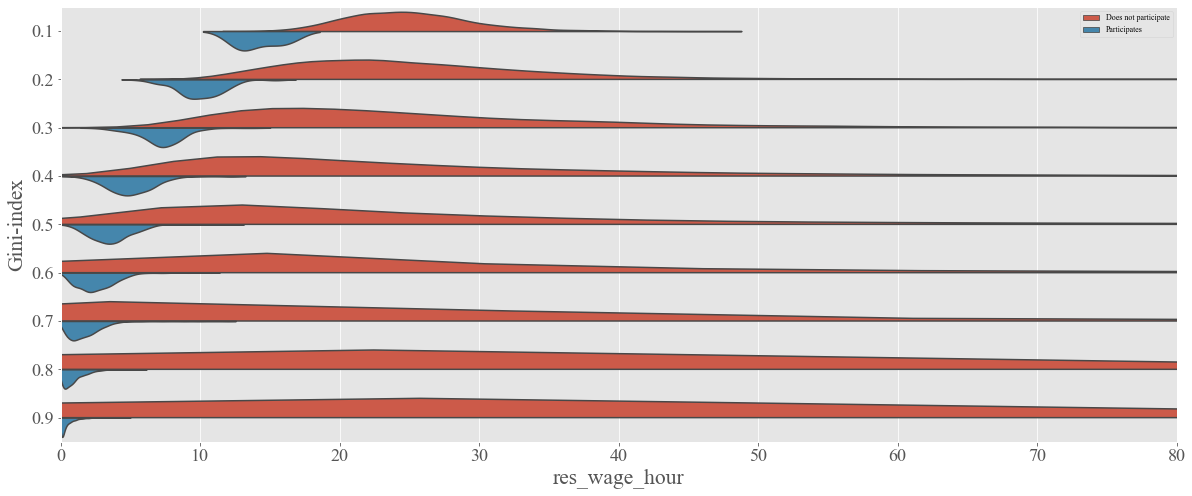

In [608]:
plt.figure(figsize=(20,8))
ax = sns.violinplot(data=complete_df_sup,x="res_wage_hour",y="scn",hue="ptcp",split=True,inner=None,orient='h',scale='width')
ax.set(xlim=(0, 80))
ax.set_ylabel('Gini-index')
ax.legend(['Does not participate','Participates'])

In [495]:
# def offset_violinplot_halves(ax, delta, width, inner, direction):
#     """
#     This function offsets the halves of a violinplot to compare tails
#     or to plot something else in between them. This is specifically designed
#     for violinplots by Seaborn that use the option `split=True`.

#     For lines, this works on the assumption that Seaborn plots everything with
#      integers as the center.

#     Args:
#      <ax>    The axis that contains the violinplots.
#      <delta> The amount of space to put between the two halves of the violinplot
#      <width> The total width of the violinplot, as passed to sns.violinplot()
#      <inner> The type of inner in the seaborn
#      <direction> Orientation of violinplot. 'hotizontal' or 'vertical'.

#     Returns:
#      - NA, modifies the <ax> directly
#     """
#     # offset stuff
#     if inner == 'sticks':
#         lines = ax.get_lines()
#         for line in lines:
#             if direction == 'horizontal':
#                 data = line.get_ydata()
#                 print(data)
#                 if int(data[0] + 1)/int(data[1] + 1) < 1:
#                     # type is top, move neg, direction backwards for horizontal
#                     data -= delta
#                 else:
#                     # type is bottom, move pos, direction backward for hori
#                     data += delta
#                 line.set_ydata(data)
#             elif direction == 'vertical':
#                 data = line.get_xdata()
#                 print(data)
#                 if int(data[0] + 1)/int(data[1] + 1) < 1:
#                     # type is left, move neg
#                     data -= delta
#                 else:
#                     # type is left, move pos
#                     data += delta
#                 line.set_xdata(data)


#     for ii, item in enumerate(ax.collections):
#         # axis contains PolyCollections and PathCollections
#         if isinstance(item, matplotlib.collections.PolyCollection):
#             # get path
#             path, = item.get_paths()
#             vertices = path.vertices
#             half_type = _wedge_dir(vertices, direction)
#             # shift x-coordinates of path
#             if half_type in ['top','bottom']:
#                if inner in ["sticks", None]:
#                     if half_type == 'top': # -> up
#                         vertices[:,1] -= delta
#                     elif half_type == 'bottom': # -> down
#                         vertices[:,1] += delta
#             elif half_type in ['left', 'right']:
#                 if inner in ["sticks", None]:
#                     if half_type == 'left': # -> left
#                         vertices[:,0] -= delta
#                     elif half_type == 'right': # -> down
#                         vertices[:,0] += delta

# def _wedge_dir(vertices, direction):
#     """
#     Args:
#       <vertices>  The vertices from matplotlib.collections.PolyCollection
#       <direction> Direction must be 'horizontal' or 'vertical' according to how
#                    your plot is laid out.
#     Returns:
#       - a string in ['top', 'bottom', 'left', 'right'] that determines where the
#          half of the violinplot is relative to the center.
#     """
#     if direction == 'horizontal':
#         result = (direction, len(set(vertices[1:5,1])) == 1)
#     elif direction == 'vertical':
#         result = (direction, len(set(vertices[-3:-1,0])) == 1)
#     outcome_key = {('horizontal', True): 'bottom',
#                    ('horizontal', False): 'top',
#                    ('vertical', True): 'left',
#                    ('vertical', False): 'right'}
#     # if the first couple x/y values after the start are the same, it
#     #  is the input direction. If not, it is the opposite
#     return outcome_key[result]

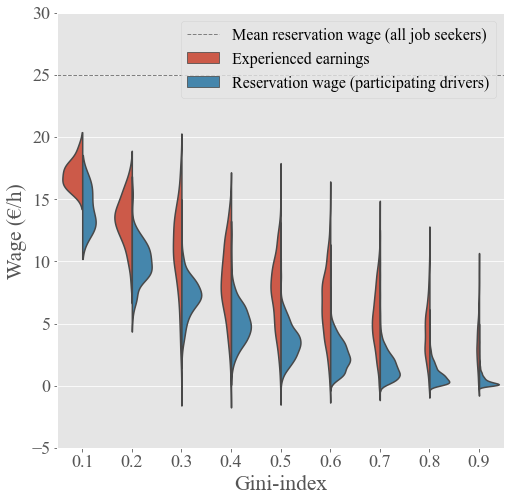

In [564]:
fig = plt.figure(figsize=(8,8))
# ax = sns.violinplot(data=complete_df_sup,x="res_wage_hour",y="scn",hue="ptcp",split=True,inner=None,orient='h')
ax = sns.violinplot(data=abc,y="value",x="scn",hue="wage_true",orient='v',split=True,inner=None,scale="area",scale_hue=True)
ax.axhline(y=25,linewidth=1, color='grey',linestyle='--')
ax.set(ylim=(-5, 30))
ax.set_xlabel('Gini-index')
ax.set_ylabel('Wage (€/h)')
ax.legend(['Mean reservation wage (all job seekers)','Experienced earnings','Reservation wage (participating drivers)'],fontsize=16,loc='upper right')
fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], 'wage-earnings.jpg'),dpi=300,bbox_inches='tight')

In [497]:
abc

,pos,res_wage,veh,scn,ptcp,exp_inc,res_wage_hour,wage_true,value
1,46482076,228.345265,1,0.1,False,NaN,28.543158,True,NaN
2,46517247,171.085141,2,0.1,False,NaN,21.385643,True,NaN
3,46253226,195.478051,3,0.1,False,NaN,24.434756,True,NaN
4,46392805,227.576024,4,0.1,False,NaN,28.447003,True,NaN
5,722976575,203.606449,5,0.1,False,NaN,25.450806,True,NaN
...,...,...,...,...,...,...,...,...,...
2496,46431377,35.499145,2496,0.9,False,NaN,4.437393,False,NaN
2497,46477622,2.662072,2497,0.9,True,2.485000,0.332759,False,2.485000
2498,46304126,0.681271,2498,0.9,True,4.564063,0.085159,False,4.564063
2499,46175654,97.971033,2499,0.9,False,NaN,12.246379,False,NaN


IndexError: index 4 is out of bounds for axis 0 with size 4

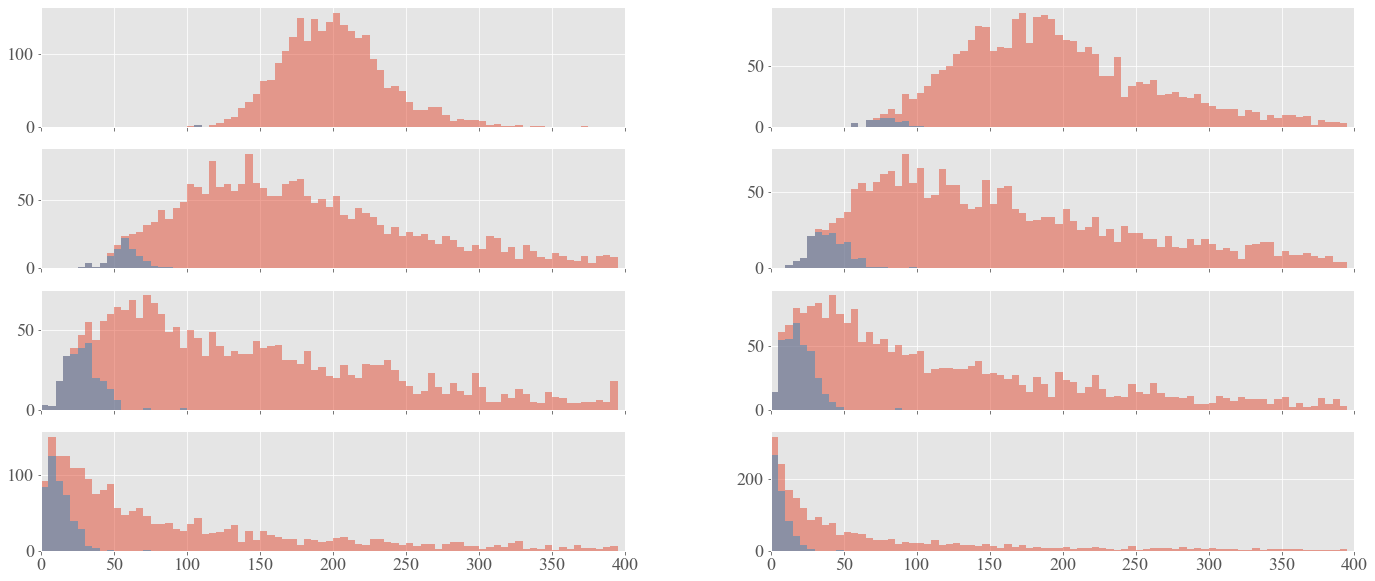

In [498]:
fig, axes = plt.subplots(4, 2, figsize = [24,10],sharex=True)
# plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.18, wspace=0.25, left=.12, right=.88)
plt.setp(axes, xlim=[0,400])

x_loc = 0
y_loc = 0
for i in sel_vals:
    run_ids = scn[scn['val'] == i].index
    abc = drivers[run_ids[0]]['res_wage']
    distr = pd.DataFrame(drivers[run_ids[0]]['res_wage'])
    distr['ptcp'] = micro.sup.ptcp[run_ids[0]]['199']
    for j in run_ids[1:]:
        abc.append(drivers[j]['res_wage'])
        temp_distr = pd.DataFrame(drivers[j]['res_wage'])
        temp_distr['ptcp'] = micro.sup.ptcp[j]['199']
        distr.append(temp_distr)
    abc.hist(density=False,alpha=0.5,ax=axes[x_loc,y_loc],bins=range(0,400,5))
    distr[distr['ptcp']]['res_wage'].hist(density=False,alpha=0.5,ax=axes[x_loc,y_loc],bins=range(0,400,5))
    y_loc += 1
    if y_loc == 2:
        y_loc = 0
        x_loc += 1

In [ ]:
micro.dem.requests[0].index.values

In [ ]:
i = 50
distr = pd.DataFrame(requests[i]['VoT'])
distr['req'] = micro.dem.requests[i]['199']
# distr.hist(bins=5)
distr
requests[i]['VoT'].hist(density=True,alpha=0.5)
distr[distr['req']]['VoT'].hist(density=True,alpha=0.5)

In [ ]:
i = 20
distr = pd.DataFrame(drivers[i]['res_wage'])
distr['ptcp'] = micro.sup.ptcp[i]['199']
# distr.hist(bins=5)
distr
drivers[i]['res_wage'].hist(density=True,alpha=0.5)
distr[distr['ptcp']]['res_wage'].hist(density=True,alpha=0.5)

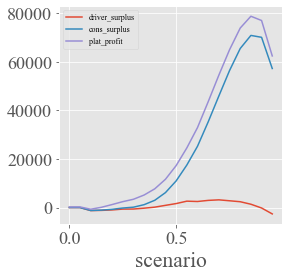

In [25]:
soc_val = pd.DataFrame()
soc_val['driver_surplus'] = eql_scn.sup.driver_surplus
soc_val['cons_surplus'] = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus
soc_val['plat_profit'] = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus + eql_scn.plf.plat_profit
ax1 = soc_val.plot()
# ax1.fill_between('driver_surplus', 0, 'plat_profit')

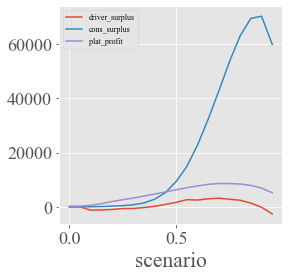

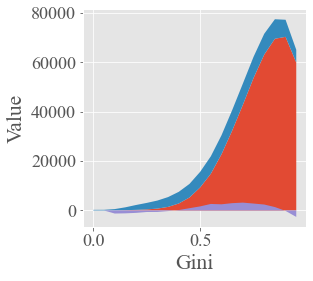

In [26]:
soc_val = pd.DataFrame()
soc_val['driver_surplus'] = eql_scn.sup.driver_surplus
soc_val['cons_surplus'] = eql_scn.dem.cons_surplus
soc_val['plat_profit'] = eql_scn.plf.plat_profit
ax1 = soc_val.plot()

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.stackplot(soc_val.index, soc_val.cons_surplus, soc_val.plat_profit)
ax.stackplot(soc_val.index, soc_val.driver_surplus)
ax.set_xlabel("Gini")
ax.set_ylabel("Value")
# ax.set_ylim(bottom=-0.5, top=1.5)
# ax.grid(which="major", color="grey", linestyle="--", linewidth=0.5)

plt.show()

In [117]:
drivers[0]

,pos,res_wage,veh
1,46482076,200.0,1
2,46517247,200.0,2
3,46253226,200.0,3
4,46392805,200.0,4
5,722976575,200.0,5
...,...,...,...
2496,46245550,200.0,2496
2497,988913697,200.0,2497
2498,46359162,200.0,2498
2499,46453487,200.0,2499


In [ ]:
requests[50].VoT.max()

In [119]:
micro.sup.keys()

odict_keys(['inform', 'regist', 'ptcp', 'perc_inc', 'exp_inc', 'particip'])

In [ ]:
np.exp(-25)

In [ ]:
np.exp(-100)

In [ ]:
np.exp(-1000)

In [ ]:
np.log(np.exp(-1000))

In [ ]:
res.dem[50]

In [ ]:
micro.dem.wait_time[50]

In [ ]:
ax1 = drivers[50].res_wage.hist(bins=500)
ax1.set_xlim([0, 500])

In [ ]:
ax1 = drivers[55].res_wage.hist(bins=500)
ax1.set_xlim([0, 500])

In [ ]:
a = 0
for i in range(0,len(res.sup)):
    one_ptcp = (res.sup[i].particip == 1)
    if one_ptcp.any():
        print('run_id {} has day with 1 participant - scenario {}'.format(i,scn.val[i]))
        a += 1
#     if res.sup[i][res.sup[i].particip == 1].shape[0] > 0:
#         print('run_id {} has one day with 1 participant'.format(i))

In [ ]:
conv_repl.head(50)

In [ ]:
res.sup[2]['rejected_reg']

In [ ]:
d2d.sup[2]

In [ ]:
res.sup[0].columns

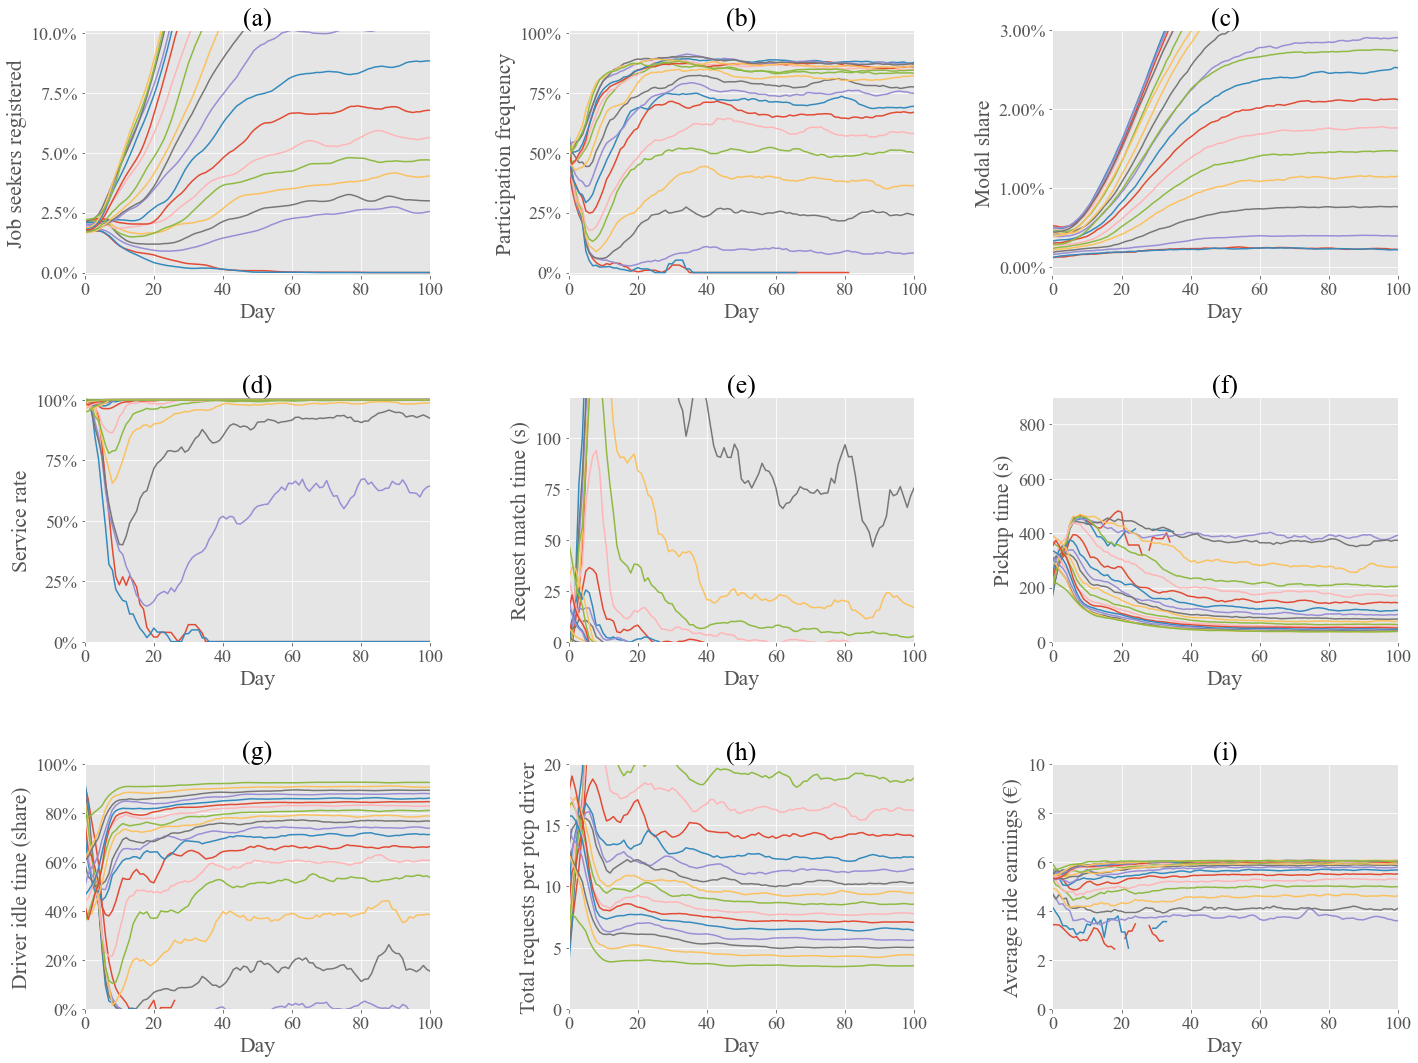

In [607]:
fig, axes = plt.subplots(3, 3, figsize = [24,18])
# plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)
plt.setp(axes, xlim=[0,100])

axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / 2500)
axes[0, 0].set_ylabel('Job seekers registered')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_title('(a)')
axes[0, 0].set_ylim(bottom = -0.001, top = 0.101)
axes[0, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[0, 0].locator_params(axis='y', nbins=5)

axes[0, 1].plot((res_scn.sup.particip / res_scn.sup.regist).rolling(5, min_periods=1).mean())
axes[0, 1].set_ylabel('Participation frequency')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_title('(b)')
axes[0, 1].set_ylim(bottom = -0.01, top = 1.01)
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 1].locator_params(axis='y', nbins=5)

axes[0, 2].plot(res_scn.dem.requests.rolling(5, min_periods=1).mean() / 75000)
axes[0, 2].set_ylabel('Modal share')
axes[0, 2].set_xlabel('Day')
axes[0, 2].set_title('(c)')
axes[0, 2].set_ylim(bottom = -0.001, top = 0.03)
axes[0, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 2].locator_params(axis='y', nbins=5)

axes[1, 0].plot(res_scn.dem.gets_offer.rolling(5, min_periods=1).mean())
axes[1, 0].set_ylabel('Service rate')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_title('(d)')
axes[1, 0].set_ylim(bottom = -0.001, top = 1.01)
axes[1, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 0].locator_params(axis='y', nbins=5)

axes[1, 1].plot(res_scn.dem.match_time.rolling(5, min_periods=1).mean())
axes[1, 1].set_ylabel('Request match time (s)')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_title('(e)')
axes[1, 1].set_ylim(bottom = 0, top = 120)
# axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axes[1, 1].locator_params(axis='y', nbins=5)

axes[1, 2].plot(res_scn.dem.pickup_time.rolling(5, min_periods=1).mean())
axes[1, 2].set_ylabel('Pickup time (s)')
axes[1, 2].set_xlabel('Day')
axes[1, 2].set_title('(f)')
axes[1, 2].set_ylim(bottom = 0, top = 900)
# axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axes[1, 2].locator_params(axis='y', nbins=5)

axes[2, 0].plot(res_scn.sup.share_idle_time.rolling(5, min_periods=1).mean())
axes[2, 0].set_ylabel('Driver idle time (share)')
axes[2, 0].set_xlabel('Day')
axes[2, 0].set_title('(g)')
axes[2, 0].set_ylim(bottom = 0, top = 1)
axes[2, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[2, 0].locator_params(axis='y', nbins=5)

axes[2, 1].plot((res_scn.dem.requests * res_scn.dem.gets_offer / res_scn.sup.particip).rolling(5, min_periods=1).mean())
axes[2, 1].set_ylabel('Total requests per ptcp driver')
axes[2, 1].set_xlabel('Day')
axes[2, 1].set_title('(h)')
axes[2, 1].set_ylim(bottom = 0, top = 20)
# axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axes[2, 1].locator_params(axis='y', nbins=5)

axes[2, 2].plot((res_scn.sup.mean_exp_inc / (res_scn.dem.requests / res_scn.sup.particip * res_scn.dem.gets_offer)).rolling(3, min_periods=1).mean())
axes[2, 2].set_ylabel('Average ride earnings (€)')
axes[2, 2].set_xlabel('Day')
axes[2, 2].set_title('(i)')
axes[2, 2].set_ylim(bottom = 0, top = 10)
# axes[1, 1].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axes[2, 2].locator_params(axis='y', nbins=5)